In [2]:
pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=1cce2ab5362dfe93c6c671067429197a27b1b338faa6a9bd64dedd2ed70c90c5
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


In [3]:
import pandas as pd
import numpy as np
import arff
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [7]:
with open('depression_data.arff', 'r', encoding='utf-8') as f:
    datafile = arff.load(f)

df_initial = pd.DataFrame(datafile['data'], columns=[attr[0] for attr in datafile['attributes']])

df_initial.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [8]:
df_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

In [9]:
df = df_initial.copy()

In [10]:
df.rename(columns={
    'Gender': 'gender',
    'Age': 'age',
    'Profession': 'profession',
    'City': 'city',
    'Academic Pressure': 'academic_pressure',
    'Work Pressure': 'work_pressure',
    'CGPA': 'cgpa',
    'Study Satisfaction': 'study_satisfaction',
    'Job Satisfaction': 'job_satisfaction',
    'Sleep Duration': 'sleep_duration',
    'Dietary Habits': 'dietary_habits',
    'Degree': 'degree',
    'Have you ever had suicidal thoughts ?': 'suicidal_thoughts',
    'Work/Study Hours': 'study_hours',
    'Financial Stress': 'financial_stress',
    'Family History of Mental Illness': 'family_mental_ilness',
    'Depression': 'depression'
    }, inplace=True)

<Figure size 1200x600 with 0 Axes>

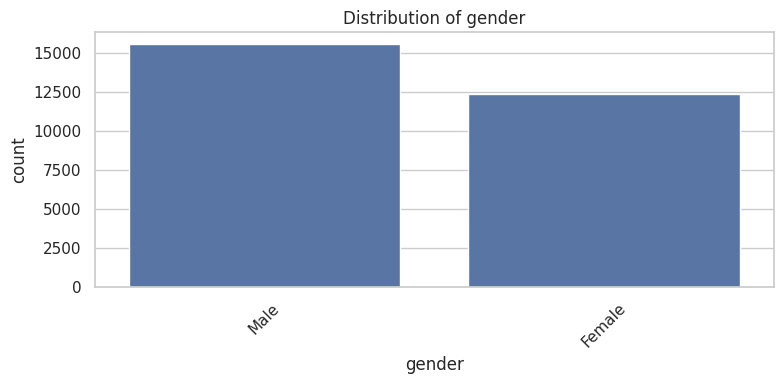

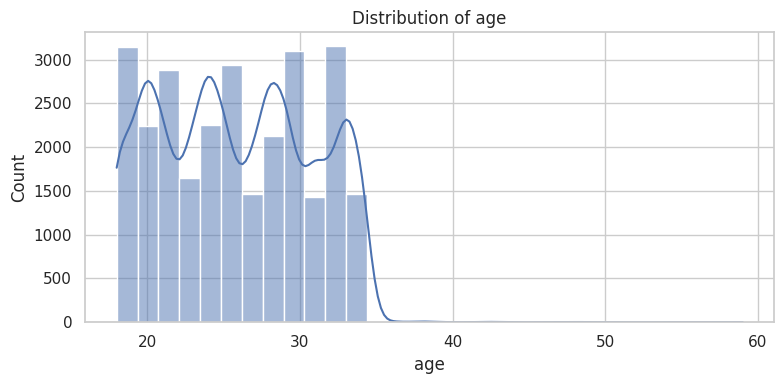

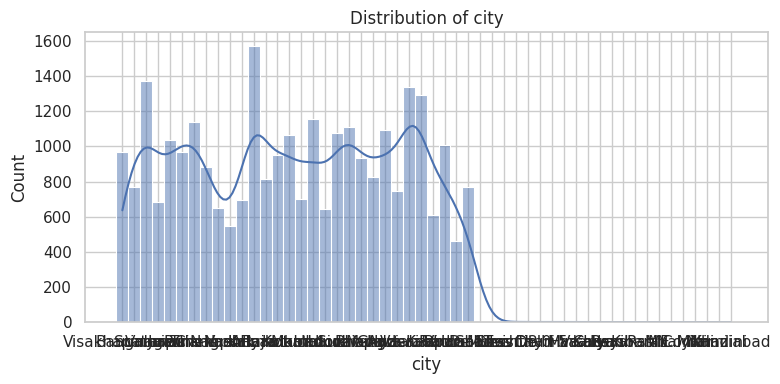

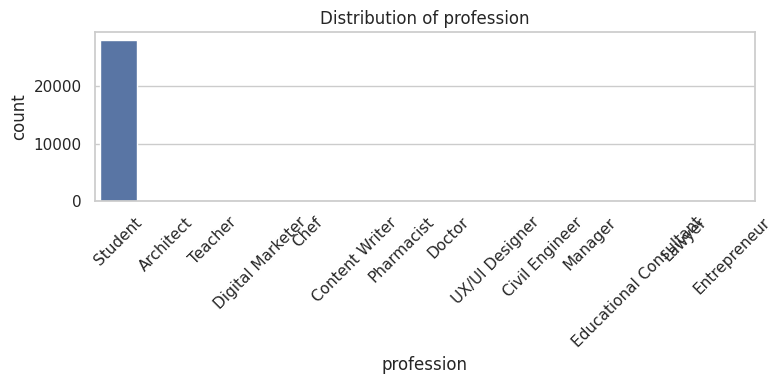

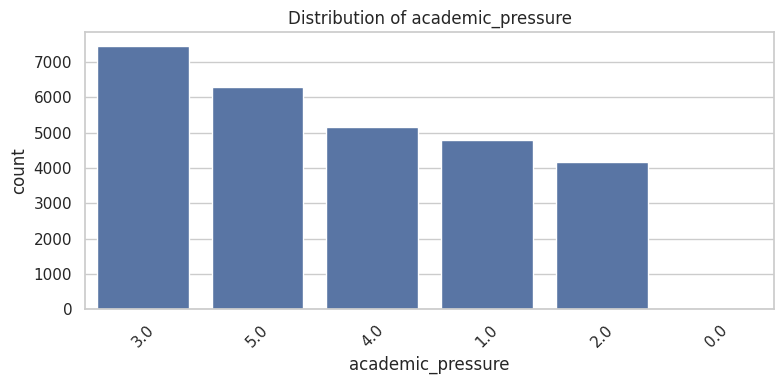

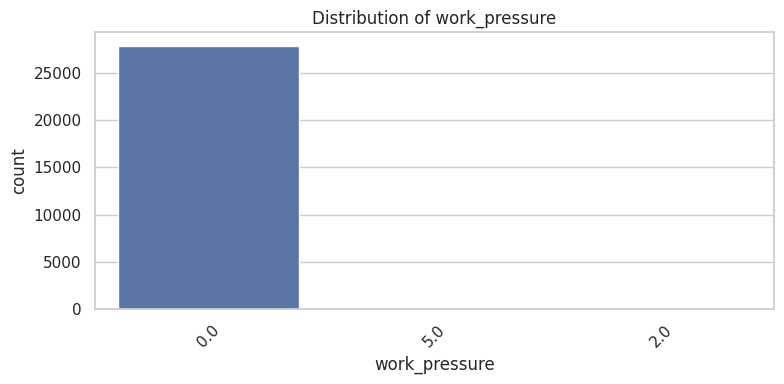

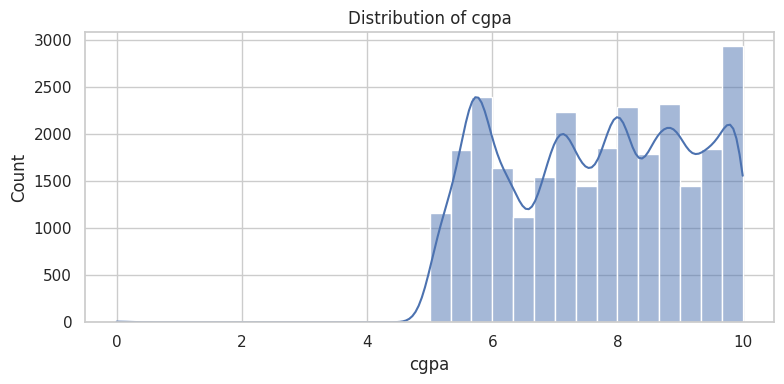

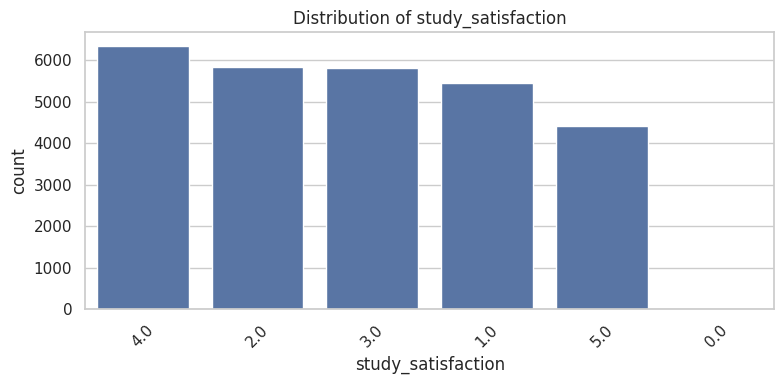

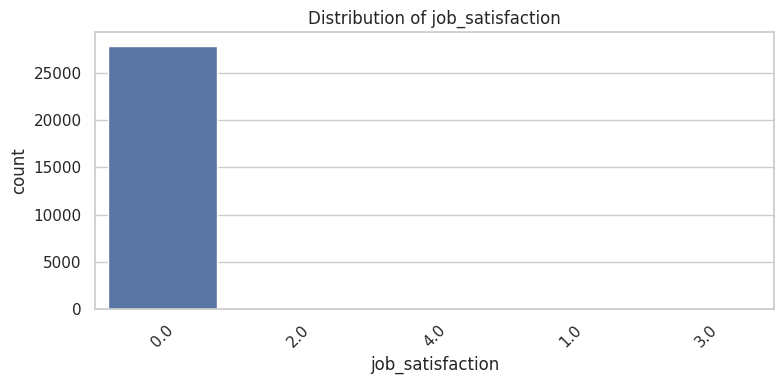

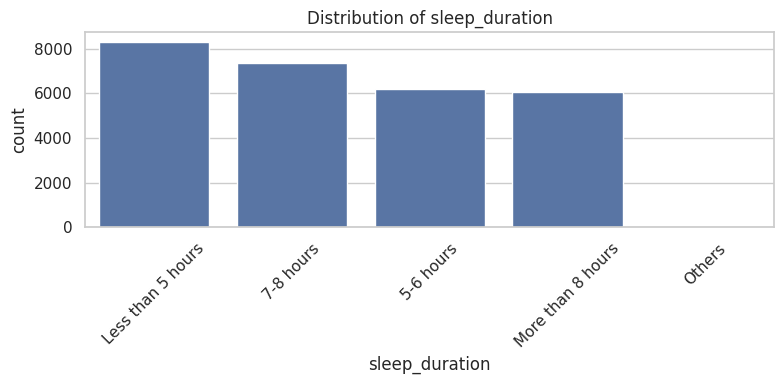

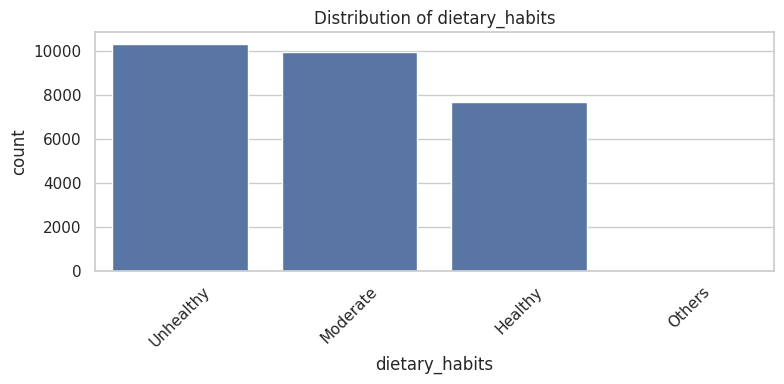

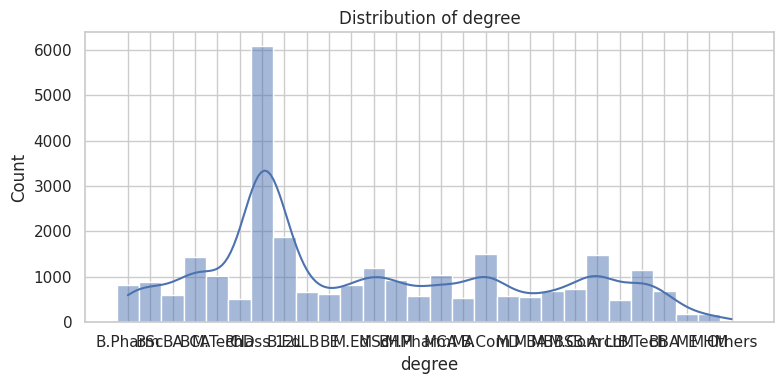

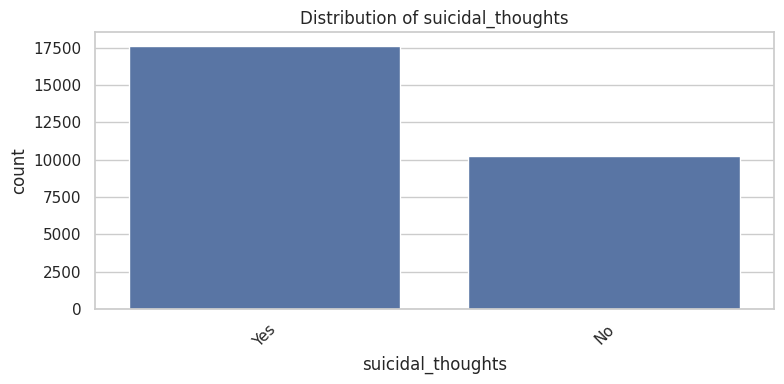

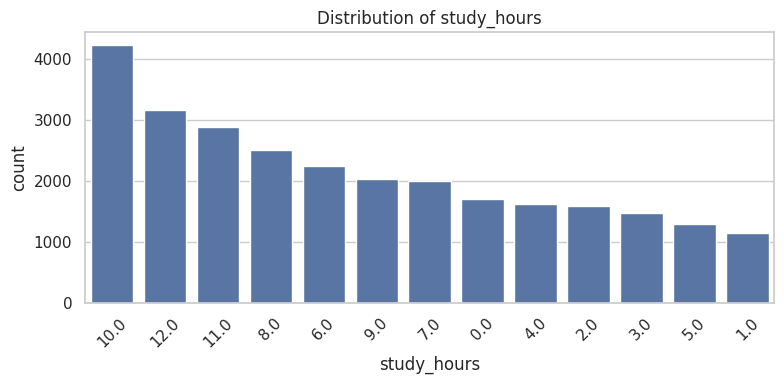

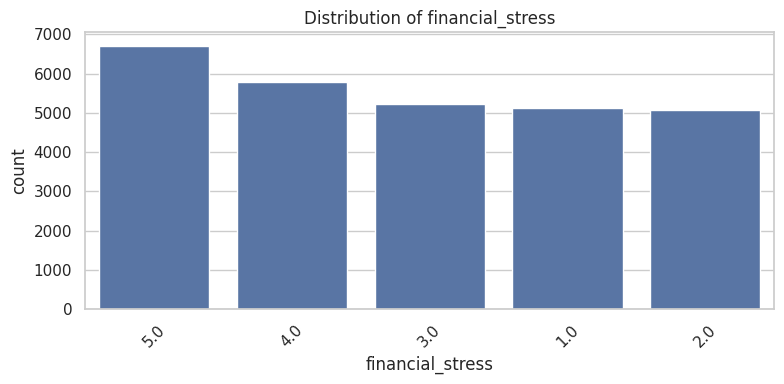

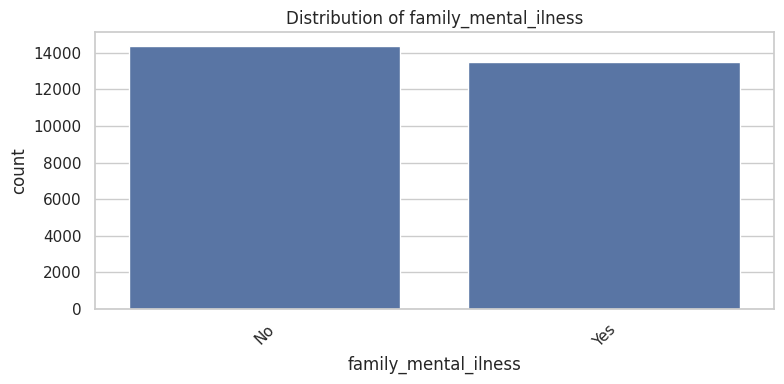

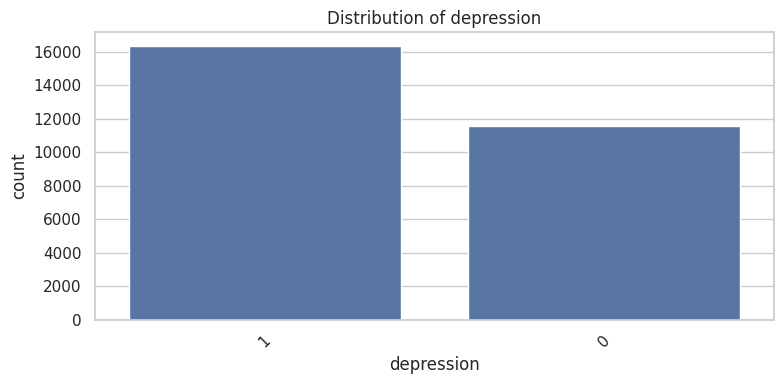

In [11]:
# features and target distribution
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

for col in df.columns:
    plt.figure(figsize=(8, 4))

    if df[col].dtype == 'category' or df[col].nunique() < 15:
        if col == "city" or col == "degree":
          sns.countplot(x=col, data=df, order=df[col].value_counts().iloc[:10].index)
          plt.title(f'Top 10 values {col}')
          plt.xticks(rotation=45)
        else:
          sns.countplot(x=col, data=df, order=df[col].value_counts().index)
          plt.title(f'Distribution of {col}')
          plt.xticks(rotation=45)
    else:
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()


In [12]:
# deleting columns job_satisfaction, work_pressure, profession (almost all rows have only one meaning in these columns)
df.drop(columns=["job_satisfaction", "work_pressure", "profession"], inplace=True)

In [23]:
# Columns sleep_duration and dietary_habits are by design - ordinal but since there are values 'Others' we cannot preprocess them as ordinal
# Possible solution - get rid of rows with 'Others' if they are not numerous

sleep_duration_counts = df['sleep_duration'].value_counts()
dietary_habits_counts = df['dietary_habits'].value_counts()
print(sleep_duration_counts)
print()
print(dietary_habits_counts)

sleep_duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

dietary_habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64


In [29]:
# deleting rows from df where value in columns 'sleep_duration', 'dietary_habits' is 'Others'

df[df[['sleep_duration', 'dietary_habits']].isin(['Others']).any(axis=1)]

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,study_hours,financial_stress,family_mental_ilness,depression
1963,Female,30.0,Ludhiana,3.0,5.42,2.0,Others,Unhealthy,B.Ed,Yes,1.0,2.0,No,0
3807,Female,18.0,Agra,3.0,6.03,4.0,Others,Unhealthy,BA,Yes,12.0,5.0,No,1
3984,Female,27.0,Ludhiana,4.0,5.08,5.0,Others,Healthy,M.Tech,Yes,8.0,5.0,Yes,1
4535,Female,22.0,Srinagar,4.0,6.92,3.0,Others,Moderate,MCA,Yes,3.0,3.0,Yes,1
5526,Female,31.0,Delhi,2.0,7.27,5.0,Others,Healthy,B.Arch,No,3.0,1.0,No,0
5684,Male,23.0,Meerut,3.0,9.98,5.0,Less than 5 hours,Others,B.Com,Yes,4.0,5.0,No,1
5786,Male,23.0,Mumbai,5.0,8.52,4.0,Others,Moderate,BE,Yes,12.0,4.0,Yes,1
6740,Male,20.0,Vasai-Virar,3.0,6.37,2.0,Others,Unhealthy,BSc,No,10.0,1.0,No,0
6892,Male,18.0,Vadodara,1.0,6.05,5.0,7-8 hours,Others,Class 12,No,4.0,4.0,No,0
7696,Male,31.0,Kalyan,3.0,8.21,4.0,Others,Moderate,BA,No,2.0,3.0,No,0


In [32]:
df.drop(df[df[['sleep_duration', 'dietary_habits']].isin(['Others']).any(axis=1)].index, inplace=True)
df[df[['sleep_duration', 'dietary_habits']].isin(['Others']).any(axis=1)]

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,study_hours,financial_stress,family_mental_ilness,depression


After having droped these "Other" values, we still have a few NA values, since it is so few relative to the total number of rows we simply drop these.

In [36]:
df[df.isna().any(axis=1)]

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,study_hours,financial_stress,family_mental_ilness,depression
4458,Female,32.0,Varanasi,3.0,5.64,1.0,5-6 hours,Healthy,BCA,No,12.0,NaN,No,1
13596,Male,29.0,Hyderabad,2.0,8.94,3.0,Less than 5 hours,Unhealthy,B.Ed,No,12.0,NaN,Yes,0
19266,Female,20.0,Kolkata,1.0,6.83,1.0,5-6 hours,Healthy,MBBS,No,9.0,NaN,Yes,0


In [39]:
df.drop(df[df.isna().any(axis=1)].index, inplace=True)
df[df.isna().any(axis=1)]

,gender,age,city,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,degree,suicidal_thoughts,study_hours,financial_stress,family_mental_ilness,depression


Ordinal features:

- academic_pressure (already in numeric form, needs Z-score standardisation / Min-Max scaling)
- study_satisfaction (already in numeric form, needs Z-score standardisation / Min-Max scaling)
- sleep_duration (needs numeric mapping, then needs Z-score standardisation / Min-Max scaling)
- financial_stress (already in numeric form, needs Z-score standardisation / Min-Max scaling)

Categorincal features:

- gender (needs OHE)
- city (needs OHE)
- dietary_habits (needs OHE)
- degree (needs OHE)
- suicidal_thoughts (needs label encoding)
- family_mental_ilness (needs label encoding)

Numerical (ratio) features:

- age (needs Z-score standardisation / Min-Max scaling)
- cgpa (needs Z-score standardisation / Min-Max scaling)
- study_hours (needs Z-score standardisation / Min-Max scaling)

In [40]:
# function for numerical mapping for 'sleep_duration':
# - 'Less than 5 hours' - 5
# - '5-6 hours' - 5.5
# - '7-8 hours' - 7.5
# - 'More than 8 hours' - 8
# name a new column as 'sleep_duration_final'


def map_sleep_duration(df):
    mapping = {
        'Less than 5 hours': 5,
        '5-6 hours': 5.5,
        '7-8 hours': 7.5,
        'More than 8 hours': 8
    }
    df['sleep_duration'] = df['sleep_duration'].map(mapping)
    return df

In [42]:
# function for label encoding for 'suicidal_thoughts' and 'family_mental_ilness': 1 if 'Yes', 0 if 'No'
def label_encoding(df):
    df['suicidal_thoughts'] = df['suicidal_thoughts'].map({'Yes': 1, 'No': 0})
    df['family_mental_ilness'] = df['family_mental_ilness'].map({'Yes': 1, 'No': 0})
    return df


In [43]:
# function for one hot encoding
columns_for_ohe = ['gender', 'city', 'dietary_habits', 'degree']

def one_hot_encoding(df, columns_for_ohe):
    return pd.get_dummies(df, columns=columns_for_ohe, drop_first=True).replace({True: 1, False: 0})

# df_encoded = one_hot_encode(df, ['gender', 'city', 'dietary_habits', 'degree'])

In [44]:
# Apply preprocessing for categorical values

df_encoded_pre = map_sleep_duration(df)
df_encoded_pre = label_encoding(df_encoded_pre)
df_encoded_pre = one_hot_encoding(df_encoded_pre, columns_for_ohe)

#df_encoded_pre.head()

There are a few values that are NA, they are very few in relation to the total sum so we can simply delete these

In [45]:
df_encoded_pre.isna().sum().sort_values(ascending=False).head(10)

df_encoded_pre = df_encoded_pre.dropna()

In [46]:
df_shuffled = df_encoded_pre.sample(frac=1, random_state=42).reset_index(drop=True)

In [55]:
df_shuffled.to_csv('depression_shuffled_notscaled.csv', index=False)